In [ ]:
%gui qt6
%matplotlib widget
import mne
import os
from data import eeg
from analysis import isc
from pathlib import Path
from ipywidgets import Layout, widgets
from IPython.display import display


working_dir = Path(os.getcwd())
if working_dir.name == "notebooks":
    working_dir = working_dir.parent

print("Working directory:", working_dir)

data_dir = Path(os.getenv("EEG_WORK_DIR", "./out"))
if not data_dir.is_absolute():
    data_dir = working_dir / data_dir



ERROR:root:
    Could not load requested Qt binding. Please ensure that
    PyQt4 >= 4.7, PyQt5, PyQt6, PySide >= 1.0.3, PySide2, or
    PySide6 is available, and only one is imported per session.

    Currently-imported Qt library:                              None
    PyQt5 available (requires QtCore, QtGui, QtSvg, QtWidgets): False
    PyQt6 available (requires QtCore, QtGui, QtSvg, QtWidgets): False
    PySide2 installed:                                          False
    PySide6 installed:                                          False
    Tried to load:                                              ['pyqt5']
    


Working directory: /home/zeyus/Projects/byd-hyperscanning-analysis


In [3]:

all_data = eeg.load_all_eeg(data_dir, preprocessed=True)



# Data Exploration

interactive(children=(Dropdown(description='Stimulus:', index=1, layout=Layout(width='auto'), options=(('Story…

<function __main__.plot_eeg_data(stimulus, subject_id, time_window, selected_channels)>

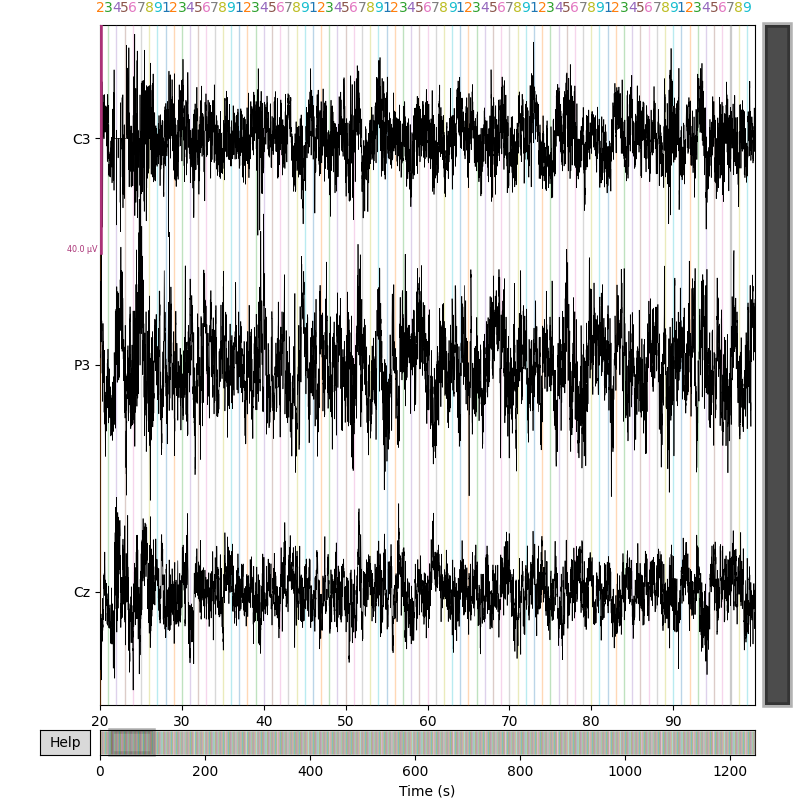

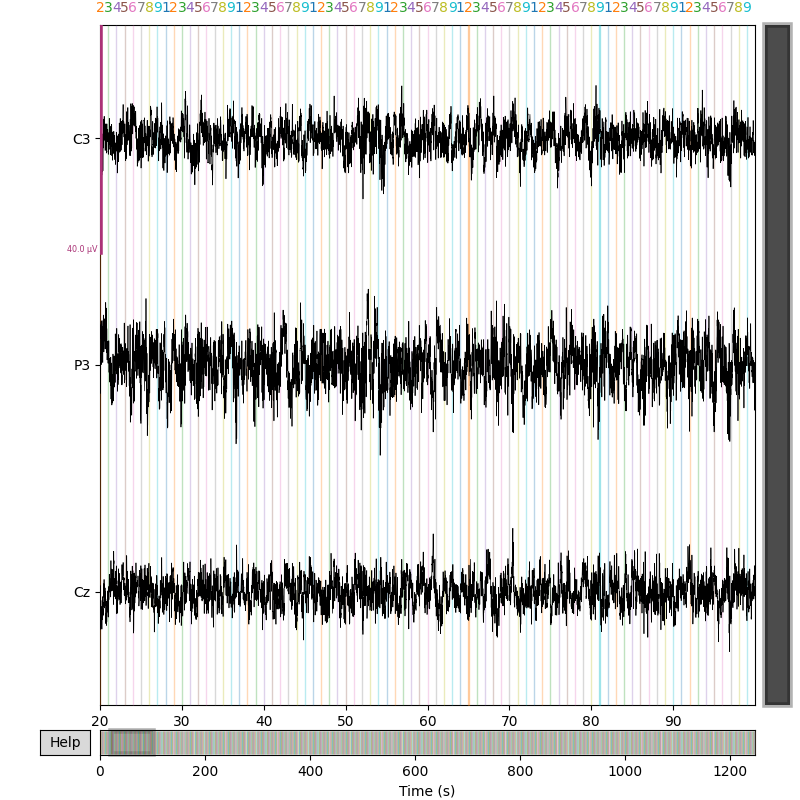

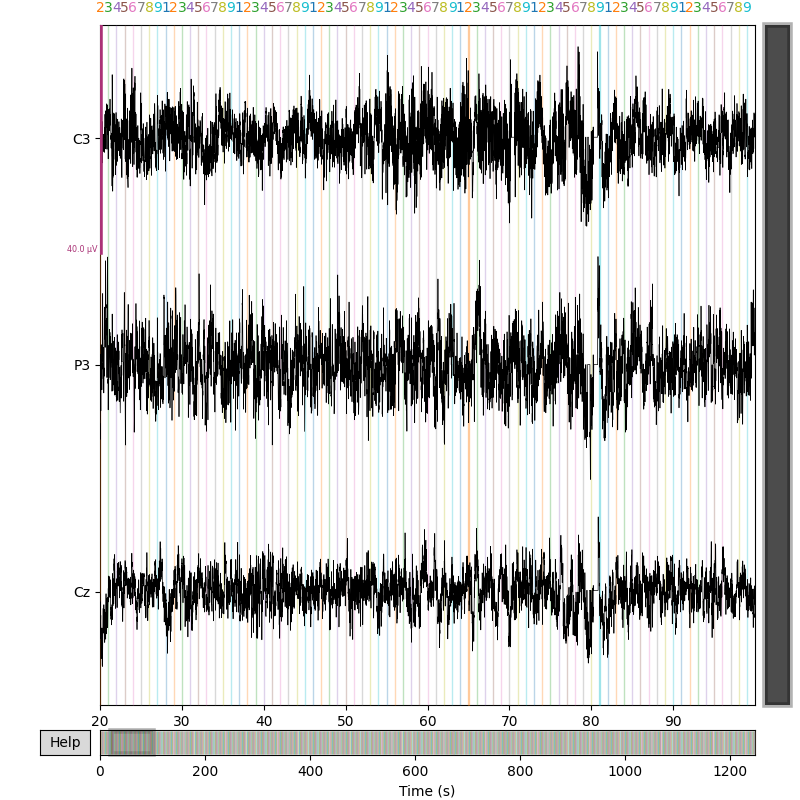

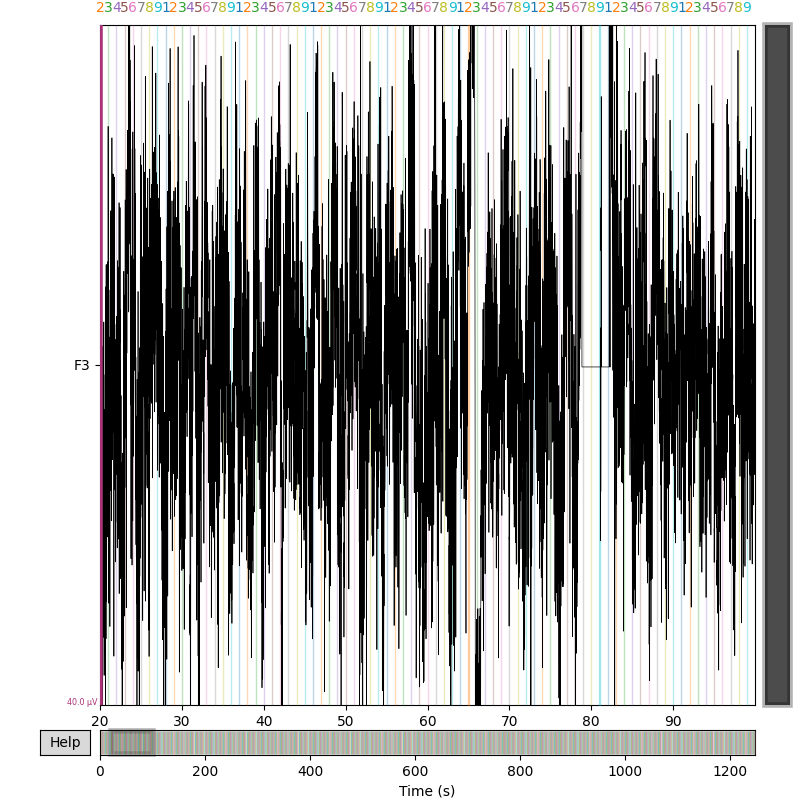

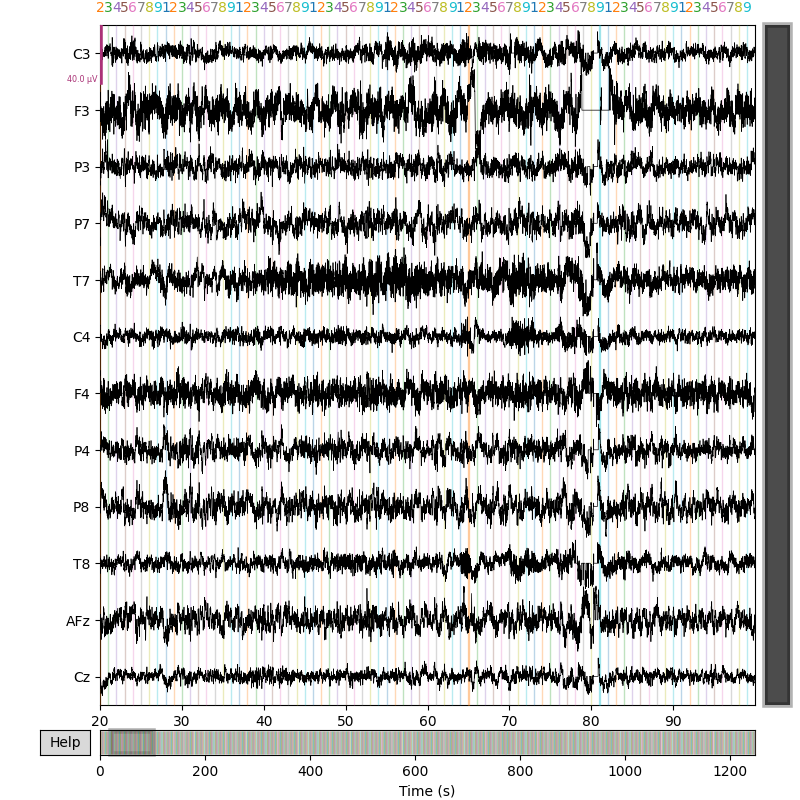

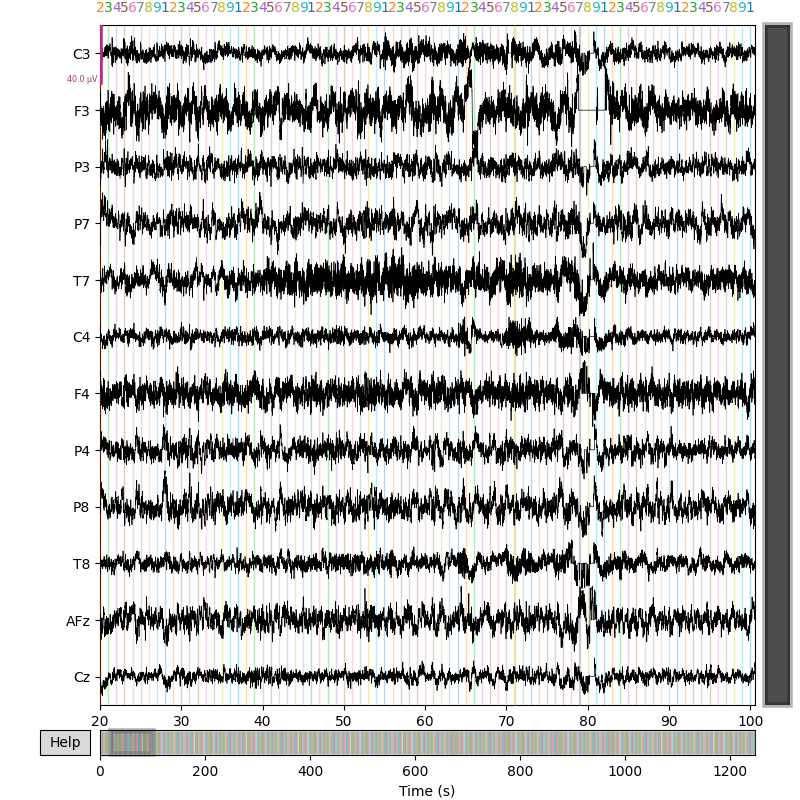

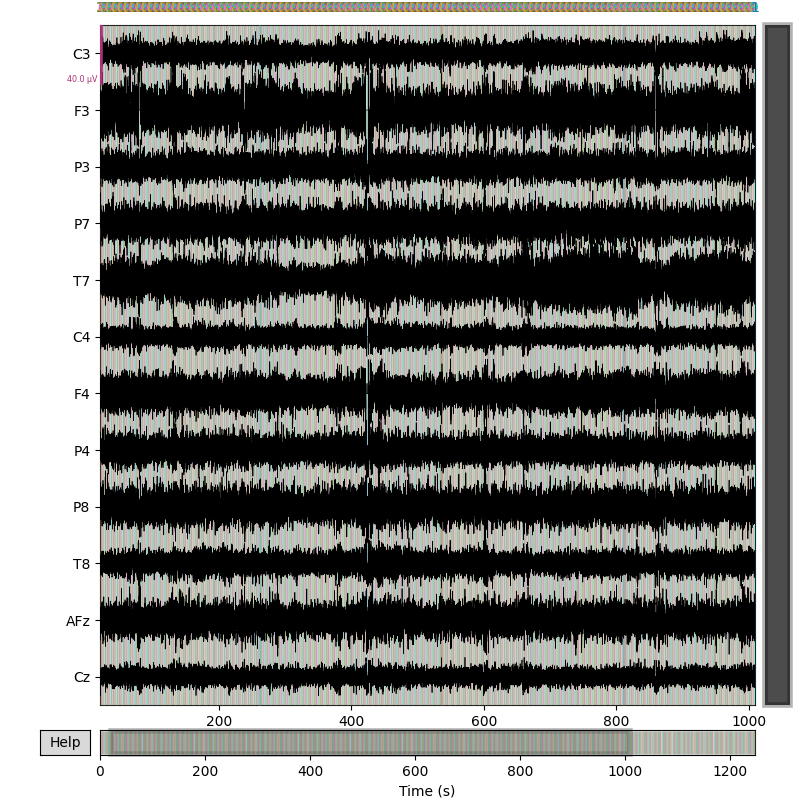

In [4]:
class EEGDataExplorer:
    def __init__(self, all_data):
        self.all_data = all_data
        self.stimulus = eeg.STIMULI[1]
        self.subject_id = eeg.SUBJECT_IDS[0]
        self.time_window = (20.0, 100.0)
        self.selected_channels = ["Cz", "P3", "C3"]
        self.raw = all_data[self.stimulus][self.subject_id]
        self.length_samples = self.raw.n_times
        

state = EEGDataExplorer(all_data)

# define layout for the widgets
label_layout = Layout(width="150px")
dropdown_layout = Layout(width="auto")

stim_select = widgets.Dropdown(
    options=[(stimulus, stimulus) for stimulus in eeg.STIMULI],
    description="Stimulus:",
    value=state.stimulus,
    disabled=False,
    layout=dropdown_layout,
)

subject_select = widgets.Dropdown(
    options=[(f"Subject {sid:02d}", sid) for sid in eeg.SUBJECT_IDS],
    description="Subject:",
    value=state.subject_id,
    disabled=False,
    layout=dropdown_layout,
)

# Show selected EEG data
time_window_slider = widgets.FloatRangeSlider(
    value=state.time_window,
    min=0.0,
    max=state.length_samples / state.raw.info["sfreq"],
    description="Time (s):",
    disabled=False,
    layout=dropdown_layout,
)

channel_selection = widgets.SelectMultiple(
    options=state.raw.ch_names,
    value=state.selected_channels,
    description="Channels:",
    disabled=False,
    rows=12,
    layout=dropdown_layout,
)



def update_time_window(time_window):
    state.time_window = time_window
    print(f"Updated time window: {time_window[0]:.2f} - {time_window[1]:.2f} seconds")

def update_channel_selection(selected_channels):
    state.selected_channels = selected_channels
    print(f"Selected channels: {', '.join(selected_channels)}")

time_window_slider.observe(lambda change: update_time_window(change['new']), names='value')
channel_selection.observe(lambda change: update_channel_selection(change['new']), names='value')


def plot_eeg_data(stimulus, subject_id, time_window, selected_channels):
    # Update state
    state.stimulus = stimulus
    state.subject_id = subject_id
    state.raw = all_data[stimulus][subject_id]
    state.length_samples = state.raw.n_times
    display(f"Showing data for Subject {subject_id:02d} - {stimulus}")
    display(f"Sample rate: {state.raw.info['sfreq']} Hz, Total duration: {state.raw.n_times / state.raw.info['sfreq']:.2f} seconds")
    display(f"Time window: {time_window[0]:.2f} - {time_window[1]:.2f} seconds")
    
    start_sample = int(time_window[0] * state.raw.info['sfreq'])
    end_sample = int(time_window[1] * state.raw.info['sfreq'])
    picks = mne.pick_channels(state.raw.info['ch_names'], include=selected_channels)
    plot = state.raw.plot(start=start_sample / state.raw.info['sfreq'], use_opengl=True, show=False, duration=(end_sample - start_sample) / state.raw.info['sfreq'], picks=picks)
    display(plot)


widgets.interact(
    plot_eeg_data,
    stimulus=stim_select,
    subject_id=subject_select,
    time_window=time_window_slider,
    selected_channels=channel_selection
)


FloatRangeSlider(value=(20.0, 99.99999999999999), description='Time (s):', max=1247.008)

SelectMultiple(description='Channels:', index=(11, 2, 0), options=('C3', 'F3', 'P3', 'P7', 'T7', 'C4', 'F4', '…

interactive(children=(Dropdown(description='Stimulus:', index=1, options=(('StoryCorps_Q&A', 'StoryCorps_Q&A')…

<function __main__.plot_eeg_data(stimulus, subject_id, time_window, selected_channels)>